# Evaluating LLM Agents: A Local Travel-Booking Agent

**#6, "Evaluating Agents"**

The notebook builds a small tool-using travel agent that searches flights and hotels and books a trip under a given budget. Part I measured accuracy, robustness, efficiency and refusals.

The travel data is self constructed. The optimal trip for every task is known.

**Models:**

- Qwen2.5-3B — `Qwen/Qwen2.5-3B-Instruct`
- Falcon3-3B — `tiiuae/Falcon3-3B-Instruct`
- SmolLM2-1.7B — `HuggingFaceTB/SmolLM2-1.7B-Instruct`

(Phi-3.5-mini and Granite-3.3-2B were also tried but had to be dropped.)

Results, transcripts, tables and charts end up in `travel_agent_results.json`/`.csv`, `travel_agent_logs.json` and the `exports/` folder.

## 0 - Setup

Load the HuggingFace token from `.env` and check that CUDA works.

In [29]:
import gc
import json
import os
import random
import time
from dataclasses import dataclass, field

import pandas as pd
import torch
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
assert HF_TOKEN, "Please create a .env file with a valid Huggingface token."
login(token=HF_TOKEN)

assert torch.cuda.is_available(), (
    "CUDA is not available. Install a CUDA build of PyTorch, e.g.\n"
    "pip install torch --index-url https://download.pytorch.org/whl/cu128"
)
print(f"torch.cuda.is_available()   : {torch.cuda.is_available()}")
print(f"torch                       : {torch.__version__}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


torch.cuda.is_available()   : True
torch                       : 2.11.0+cu128


## 1 - Travel database

Create the database of flights, routes, cities, and hotels.

In [30]:
rng = random.Random(67)  # fixed rng seed

ROUTES = [("Berlin", "Lisbon"), ("Munich", "Barcelona"), ("Hamburg", "Rome")]
DEST_CITIES = [dest for _, dest in ROUTES]

AIRLINES = ["Lufthansa", "Ryanair", "easyJet", "TAP", "Vueling", "Eurowings", "Wizz Air"]
HOTEL_NAMES = ["Rosewood", "Four Seasons", "Capella", "Passalacqua", "Raffles",
                "Atlantis The Royal", "Mandarin Oriental", "Chable Yacatan", "Upper House", "Copacabana"]


def make_flights():
    """7 flight options per route"""
    flights, n = {}, 1
    for origin, dest in ROUTES:
        options = []
        for _ in range(7):
            options.append({
                "flight_id": f"FL{n:03d}",
                "airline": rng.choice(AIRLINES),
                "origin": origin,
                "destination": dest,
                "departure": f"{rng.randint(6, 21):02d}:{rng.choice(['00', '15', '30', '45'])}", # departure times from 6:00 to 21:45
                "duration": round(rng.uniform(2.0, 4.5), 1), # durations from 2.0 to 4.5, rounded
                "price": rng.randint(50, 420),
            })
            n += 1
        flights[(origin, dest)] = options
    return flights


def make_hotels():
    """8 hotels per destination city"""
    hotels, n = {}, 1
    for city in DEST_CITIES:
        options = []
        for name in rng.sample(HOTEL_NAMES, 8):
            stars = rng.randint(1, 5)
            base = {1: 30, 2: 45, 3: 70, 4: 110, 5: 180}[stars]
            options.append({
                "hotel_id": f"HT{n:03d}",
                "name": f"{name} {city}",
                "city": city,
                "stars": stars,
                "guest_rating": round(min(10.0, rng.uniform(2.0 * stars - 1.0, 2.0 * stars + 1.0)), 1), # ratings from 1 to 10, correlated with stars
                "price_per_night": base + rng.randint(0, base),
            })
            n += 1
        hotels[city] = options
    return hotels


FLIGHTS = make_flights()
HOTELS = make_hotels()

print("Route: Berlin -> Lisbon")
display(pd.DataFrame(FLIGHTS[("Berlin", "Lisbon")]))
print("City: Lisbon")
display(pd.DataFrame(HOTELS["Lisbon"]))

Route: Berlin -> Lisbon


,flight_id,airline,origin,destination,departure,duration,price
0,FL001,Lufthansa,Berlin,Lisbon,09:45,4.4,262
1,FL002,easyJet,Berlin,Lisbon,19:45,3.6,154
2,FL003,Eurowings,Berlin,Lisbon,07:15,2.7,130
3,FL004,TAP,Berlin,Lisbon,11:00,3.7,301
4,FL005,easyJet,Berlin,Lisbon,13:45,3.9,352
5,FL006,Lufthansa,Berlin,Lisbon,18:15,4.4,239
6,FL007,Vueling,Berlin,Lisbon,06:45,3.9,169


City: Lisbon


,hotel_id,name,city,stars,guest_rating,price_per_night
0,HT001,Raffles Lisbon,Lisbon,5,9.7,208
1,HT002,Rosewood Lisbon,Lisbon,3,6.4,78
2,HT003,Passalacqua Lisbon,Lisbon,5,9.7,353
3,HT004,Four Seasons Lisbon,Lisbon,1,1.7,60
4,HT005,Mandarin Oriental Lisbon,Lisbon,2,4.7,52
5,HT006,Chable Yacatan Lisbon,Lisbon,2,4.0,51
6,HT007,Upper House Lisbon,Lisbon,5,9.1,253
7,HT008,Atlantis The Royal Lisbon,Lisbon,3,6.5,109


### 1.1 - Tools

Define the three agent tools: `search_flights`, `search_hotels` and `book_trip`. Bad input returns an error dict instead of an exception.

In [44]:
class TravelToolbox:
    """Toolbox for the agent tools"""

    def __init__(self):
        self.booking = None

    def search_flights(self, origin=None, destination=None, **extra):
        origin = str(origin).strip().title()
        destination = str(destination).strip().title()
        if (origin, destination) not in FLIGHTS:
            available = [o + " -> " + d for (o, d) in FLIGHTS]
            return {"error": f"No flights from {origin} to {destination}. Available routes: {available}"}
        return FLIGHTS[(origin, destination)]

    def search_hotels(self, city=None, **extra):
        city = str(city).strip().title()
        if city not in HOTELS:
            return {"error": f"No hotels found in {city}. Cities with hotels: {list(HOTELS)}"}
        return HOTELS[city]

    def book_trip(self, flight_id=None, hotel_id=None, nights=None, **extra):
        flight = None
        for options in FLIGHTS.values():
            for f in options:
                if f["flight_id"] == flight_id:
                    flight = f
        hotel = None
        for options in HOTELS.values():
            for h in options:
                if h["hotel_id"] == hotel_id:
                    hotel = h

        if flight is None:
            return {"error": f"Unknown flight_id {flight_id}, use an id from search_flights."}
        if hotel is None:
            return {"error": f"Unknown hotel_id {hotel_id}, use an id from search_hotels."}
        if hotel["city"] != flight["destination"]:
            return {"error": f"Hotel {hotel_id} is in {hotel['city']}, but the flight goes to {flight['destination']}."}
        try:
            nights = int(nights)
        except (TypeError, ValueError):
            return {"error": "Argument 'nights' must be an integer."}
        if nights <= 0:
            return {"error": "Argument 'nights' must be a positive integer."}

        total = flight["price"] + nights * hotel["price_per_night"]
        self.booking = {"flight": flight, "hotel": hotel, "nights": nights, "total_cost": total}
        return {"confirmation": "BOOKED", "flight_id": flight_id, "hotel_id": hotel_id,
                "nights": nights, "total_cost": total}

    def call(self, name, args):
        if not isinstance(args, dict):
            return {"error": "'args' must be a JSON object."}
        try:
            if name == "search_flights":
                return self.search_flights(**args)
            elif name == "search_hotels":
                return self.search_hotels(**args)
            elif name == "book_trip":
                return self.book_trip(**args)
            else:
                return {"error": f"Unknown tool {name}."}
        except TypeError as e:
            return {"error": f"Bad arguments for {name}: {e}"}


tb = TravelToolbox()
print(tb.call("search_flights", {"origin": "Bochum", "destination": "Lisbon"}))
print(tb.call("test", {}))
print(tb.call("book_trip", {"flight_id": "FL001", "hotel_id": "HT001", "nights": 3}))

{'error': "No flights from Bochum to Lisbon. Available routes: ['Berlin -> Lisbon', 'Munich -> Barcelona', 'Hamburg -> Rome']"}
{'error': 'Unknown tool test.'}
{'confirmation': 'BOOKED', 'flight_id': 'FL001', 'hotel_id': 'HT001', 'nights': 3, 'total_cost': 886}


## 2 - The agent

Define the system prompt, the tool-call parser and the agent itself. The model calls tools via JSON and ends with "FINAL ANSWER:", up to `MAX_TURNS` LLM calls.

In [ ]:
SYSTEM_PROMPT = """You are TravelBooker, an AI travel agent. You find and book flights and hotels for the user.

You can use these tools:
1. search_flights(origin: str, destination: str) -> round-trip flight options with flight_id, airline, departure, duration and price (total round-trip price).
2. search_hotels(city: str) -> hotel options with hotel_id, name, stars, guest_rating and price_per_night.
3. book_trip(flight_id: str, hotel_id: str, nights: int) -> books the flight and the hotel for that many nights and returns the total cost.

How to respond:
- First think step by step in plain text: compare the prices, compute total = flight price + nights * hotel price_per_night for your candidate, and check it against the user's budget.
- Then, to call a tool, end your reply with exactly ONE JSON object on its own line, e.g.:
  {"tool": "search_flights", "args": {"origin": "Berlin", "destination": "Lisbon"}}
- Call one tool at a time and wait for its result.
- Always search flights and hotels before booking.
- Only call book_trip if your computed total is <= the user's budget. If it exceeds the budget, choose a cheaper flight or hotel and re-check.
- After a successful booking, reply with plain text (no JSON) starting with "FINAL ANSWER:" summarising the trip and total cost.
- If NO combination fits the budget, do not book anything; reply with "FINAL ANSWER:" (no JSON) explaining that the budget is insufficient.
"""

MAX_TURNS = 8
MAX_NEW_TOKENS = 400


def extract_tool_call(text):
    """Extract the last JSON tool call from the reply"""
    found, start = None, text.find("{")
    while start != -1:
        depth = 0
        for i in range(start, len(text)):
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
                if depth == 0:
                    try:
                        cand = json.loads(text[start:i + 1])
                        if isinstance(cand, dict) and "tool" in cand:
                            found = cand
                    except json.JSONDecodeError:
                        pass
                    break
        start = text.find("{", start + 1)
    return found


@dataclass
class EpisodeLog:
    """Telemetry for one agent episode"""
    model: str
    scenario_id: str
    variant: str
    llm_calls: int = 0
    gen_tokens: int = 0
    wall_time_s: float = 0.0
    tool_calls: int = 0
    tool_errors: int = 0
    parse_failures: int = 0
    finished: bool = False          # gave a FINAL ANSWER before the turn limit
    final_text: str = ""
    booking: dict | None = None
    transcript: list = field(default_factory=list)


def generate_reply(model, tokenizer, messages):
    """Generate one model reply for the conversation"""
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(model.device)
    t0 = time.perf_counter()
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
        )
    dt = time.perf_counter() - t0
    new_tokens = out[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip(), len(new_tokens), dt


def run_agent(model, tokenizer, model_name, scenario_id, variant, user_prompt):
    """Run one agent episode"""
    toolbox = TravelToolbox()
    log = EpisodeLog(model=model_name, scenario_id=scenario_id, variant=variant)
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt}]

    for _ in range(MAX_TURNS):
        text, n_tok, dt = generate_reply(model, tokenizer, messages)
        log.llm_calls += 1
        log.gen_tokens += n_tok
        log.wall_time_s += dt
        messages.append({"role": "assistant", "content": text})

        call = extract_tool_call(text)
        if call is not None:
            log.tool_calls += 1
            result = toolbox.call(str(call.get("tool")), call.get("args", {}))
            if isinstance(result, dict) and "error" in result:
                log.tool_errors += 1
            messages.append({"role": "user",
                             "content": f"TOOL RESULT for {call.get('tool')}:\n"
                                        f"{json.dumps(result, ensure_ascii=False)}"})
            continue

        if "FINAL ANSWER" in text.upper():
            log.finished = True
            log.final_text = text
            break

        log.parse_failures += 1
        messages.append({"role": "user", "content": (
            'ERROR: I could not parse a tool call in your reply. Reply with ONLY one JSON object like '
            '{"tool": "search_flights", "args": {"origin": "Berlin", "destination": "Lisbon"}} '
            'or give your final answer starting with "FINAL ANSWER:".')})

    log.booking = toolbox.booking
    log.transcript = messages
    return log

## 3 - Evaluation design

Create seven scenarios with budget tiers (tight = 1.15x the cheapest trip, medium = 1.5x, generous = 2.5x, infeasible = 0.5x) and three phrasings (clean, paraphrase, noisy).

In [ ]:
def cheapest_combo(origin, destination, nights):
    """Price of the cheapest valid flight+hotel combination"""
    flight = min(FLIGHTS[(origin, destination)], key=lambda f: f["price"])
    hotel = min(HOTELS[destination], key=lambda h: h["price_per_night"])
    return flight["price"] + nights * hotel["price_per_night"]


BUDGET_TIERS = {"tight": 1.15, "medium": 1.5, "generous": 2.5, "infeasible": 0.5}


def make_scenario(origin, destination, nights, tier):
    optimal = cheapest_combo(origin, destination, nights)
    budget = int(round(optimal * BUDGET_TIERS[tier] / 10) * 10)
    return {"scenario_id": f"{origin[:3]}-{destination[:3]}-{nights}n-{tier}".lower(),
            "origin": origin, "destination": destination, "nights": nights,
            "tier": tier, "budget": budget, "optimal_cost": optimal,
            "feasible": tier != "infeasible"}


SCENARIOS = [
    make_scenario("Berlin", "Lisbon", 4, "tight"),
    make_scenario("Berlin", "Lisbon", 4, "generous"),
    make_scenario("Munich", "Barcelona", 3, "tight"),
    make_scenario("Munich", "Barcelona", 3, "medium"),
    make_scenario("Hamburg", "Rome", 5, "medium"),
    make_scenario("Hamburg", "Rome", 5, "generous"),
    make_scenario("Berlin", "Lisbon", 4, "infeasible"),
]


def variant_prompts(s):
    """The same task in three phrasings"""
    o, d, n, b = s["origin"], s["destination"], s["nights"], s["budget"]
    return {
        "clean": (f"I need to plan a trip from {o} to {d} for {n} nights. "
                  f"My total budget for the round-trip flight plus hotel is {b} EUR. "
                  f"Please find the options and book the best trip within my budget."),
        "paraphrase": (f"Could you sort out a little getaway to {d} for me? I'd fly out of {o} "
                       f"and stay {n} nights. Whatever you pick, flight and hotel together must "
                       f"stay under {b} euros — go ahead and book the best fit."),
        "noisy": (f"hi!! im lookin to travel form {o} to {d} for {n} nigths :) btw my friend "
                  f"said the food there is amazing lol. totl budget is {b} eur for flite + hotel "
                  f"together, plz book somthing nice thx!!"),
    }


pd.DataFrame(SCENARIOS)

### 3.1 - Scoring an episode

Score one episode: success, over-budget, wrong trip, cost optimality and efficiency.

In [ ]:
def evaluate_episode(log, scenario):
    """Score one episode against its scenario"""
    booked = log.booking is not None
    within = booked and log.booking["total_cost"] <= scenario["budget"]
    right_trip = booked and (
        log.booking["flight"]["origin"] == scenario["origin"]
        and log.booking["flight"]["destination"] == scenario["destination"]
        and log.booking["nights"] == scenario["nights"]
    )
    if scenario["feasible"]:
        success = booked and within and right_trip
    else:
        # infeasible budget: the only correct behaviour is NOT booking and saying so
        success = (not booked) and log.finished

    cost_opt = (round(scenario["optimal_cost"] / log.booking["total_cost"], 3)
                if (scenario["feasible"] and success) else None)

    return {
        "model": log.model, "scenario_id": scenario["scenario_id"], "tier": scenario["tier"],
        "variant": log.variant, "feasible": scenario["feasible"],
        "success": success, "booked": booked,
        "over_budget": bool(booked and not within),
        "wrong_trip": bool(booked and not right_trip),
        "gave_final_answer": log.finished,
        "llm_calls": log.llm_calls, "tool_calls": log.tool_calls,
        "tool_errors": log.tool_errors, "parse_failures": log.parse_failures,
        "gen_tokens": log.gen_tokens, "wall_time_s": round(log.wall_time_s, 2),
        "total_cost": log.booking["total_cost"] if booked else None,
        "budget": scenario["budget"], "cost_optimality": cost_opt,
    }

## 4 - Models

Load the three models one at a time in bfloat16 to keep VRAM usage low. Other models can be swapped in via `MODELS`.

In [35]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()  # silence generation-config warnings

MODELS = {
    "Qwen2.5-3B": "Qwen/Qwen2.5-3B-Instruct",
    "Falcon3-3B": "tiiuae/Falcon3-3B-Instruct",
    "SmolLM2-1.7B": "HuggingFaceTB/SmolLM2-1.7B-Instruct",
}
MODEL_ORDER = list(MODELS)


def load_model(repo_id):
    tokenizer = AutoTokenizer.from_pretrained(repo_id, token=HF_TOKEN)
    model = AutoModelForCausalLM.from_pretrained(
        repo_id,
        dtype=torch.bfloat16,
        device_map="cuda",
        attn_implementation="sdpa",
        token=HF_TOKEN,
    )
    model.eval()
    return model, tokenizer

## 5 - Run the experiment

7 scenarios x 3 prompt variants x 3 models = 63 episodes. Results are saved after every episode, so an interrupted run continues where it stopped. To start fresh, delete `travel_agent_results.json` and `travel_agent_logs.json`.

In [ ]:
from dataclasses import asdict

from tqdm.auto import tqdm

RESULTS_PATH = "travel_agent_results.json"
LOGS_PATH = "travel_agent_logs.json"

all_results = json.load(open(RESULTS_PATH, encoding="utf-8")) if os.path.exists(RESULTS_PATH) else []
all_logs = json.load(open(LOGS_PATH, encoding="utf-8")) if os.path.exists(LOGS_PATH) else []
done = {(r["model"], r["scenario_id"], r["variant"]) for r in all_results}
if done:
    print(f"Resuming: {len(done)} episodes already recorded — they will be skipped.")

for model_name, repo_id in MODELS.items():
    jobs = [(s, v, p) for s in SCENARIOS for v, p in variant_prompts(s).items()
            if (model_name, s["scenario_id"], v) not in done]
    if not jobs:
        print(f"=== {model_name}: already complete, skipping ===")
        continue
    print(f"\n=== {model_name}  ({repo_id}) — {len(jobs)} episodes to run ===")
    model, tokenizer = load_model(repo_id)

    for scenario, variant, prompt in tqdm(jobs, desc=model_name):
        log = run_agent(model, tokenizer, model_name, scenario["scenario_id"], variant, prompt)
        all_logs.append(asdict(log))
        all_results.append(evaluate_episode(log, scenario))
        with open(RESULTS_PATH, "w", encoding="utf-8") as f:
            json.dump(all_results, f, indent=2)
        with open(LOGS_PATH, "w", encoding="utf-8") as f:
            json.dump(all_logs, f, ensure_ascii=False, indent=1)

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nDone — {len(all_results)} episodes in {RESULTS_PATH}")

Resuming: 63 episodes already recorded — they will be skipped.
=== Qwen2.5-3B: already complete, skipping ===
=== Falcon3-3B: already complete, skipping ===
=== SmolLM2-1.7B: already complete, skipping ===

Done — 63 episodes in travel_agent_results.json


### 5.1 - A peek inside one episode

Print one full conversation (change the index to browse others).

In [37]:
all_logs = json.load(open("travel_agent_logs.json", encoding="utf-8"))

example = next((l for l in all_logs if l["booking"] is not None), all_logs[0])
print(f"model={example['model']}  scenario={example['scenario_id']}  variant={example['variant']}\n")
for msg in example["transcript"][1:]:  # skip the long system prompt
    text = msg["content"]
    print(f"--- {msg['role'].upper()} " + "-" * 50)
    print(text if len(text) < 700 else text[:700] + " [...truncated...]")

model=Qwen2.5-3B  scenario=ber-lis-4n-tight  variant=clean

--- USER --------------------------------------------------
I need to plan a trip from Berlin to Lisbon for 4 nights. My total budget for the round-trip flight plus hotel is 380 EUR. Please find the options and book the best trip within my budget.
--- ASSISTANT --------------------------------------------------
{"tool": "search_flights", "args": {"origin": "Berlin", "destination": "Lisbon"}}
--- USER --------------------------------------------------
TOOL RESULT for search_flights:
[{"flight_id": "FL001", "airline": "Lufthansa", "origin": "Berlin", "destination": "Lisbon", "departure": "09:45", "duration_h": 4.4, "price_eur": 262}, {"flight_id": "FL002", "airline": "easyJet", "origin": "Berlin", "destination": "Lisbon", "departure": "19:45", "duration_h": 3.6, "price_eur": 154}, {"flight_id": "FL003", "airline": "Eurowings", "origin": "Berlin", "destination": "Lisbon", "departure": "07:15", "duration_h": 2.7, "price_eur": 130}

## 6 - Results

### 6.1 - Aggregate table

In [38]:
# Analysis is file-based: this and all cells below run in a fresh kernel without
# re-running the experiment. Exported tables/charts land in exports/ (for the slide deck).
EXPORT_DIR = "exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

df = pd.DataFrame(json.load(open("travel_agent_results.json", encoding="utf-8")))
df.to_csv("travel_agent_results.csv", index=False)


def aggregate(g):
    return pd.Series({
        "success_rate": g["success"].mean(),
        "over_budget_rate": g["over_budget"].mean(),
        "wrong_trip_rate": g["wrong_trip"].mean(),
        "tool_error_rate": g["tool_errors"].sum() / max(g["tool_calls"].sum(), 1),
        "parse_failure_rate": g["parse_failures"].sum() / g["llm_calls"].sum(),
        "avg_llm_calls": g["llm_calls"].mean(),
        "avg_gen_tokens": g["gen_tokens"].mean(),
        "avg_episode_time_s": g["wall_time_s"].mean(),
        "tokens_per_s": g["gen_tokens"].sum() / g["wall_time_s"].sum(),
        "avg_cost_optimality": g["cost_optimality"].dropna().mean(),
    })


summary = df.groupby("model").apply(aggregate).reindex(MODEL_ORDER)
summary.round(3).to_csv(f"{EXPORT_DIR}/summary_by_model.csv")
summary.round(3)

,success_rate,over_budget_rate,wrong_trip_rate,tool_error_rate,parse_failure_rate,avg_llm_calls,avg_gen_tokens,avg_episode_time_s,tokens_per_s,avg_cost_optimality
model,,,,,,,,,,
Qwen2.5-3B,0.381,0.524,0.0,0.000,0.020,4.762,316.190,10.066,31.411,0.916
Falcon3-3B,0.143,0.000,0.0,0.706,0.000,1.762,194.286,3.513,55.300,NaN
SmolLM2-1.7B,0.000,0.000,0.0,0.692,0.057,7.476,1992.095,27.834,71.571,NaN


### 6.2 - Charts

One fixed colour per model across all charts.

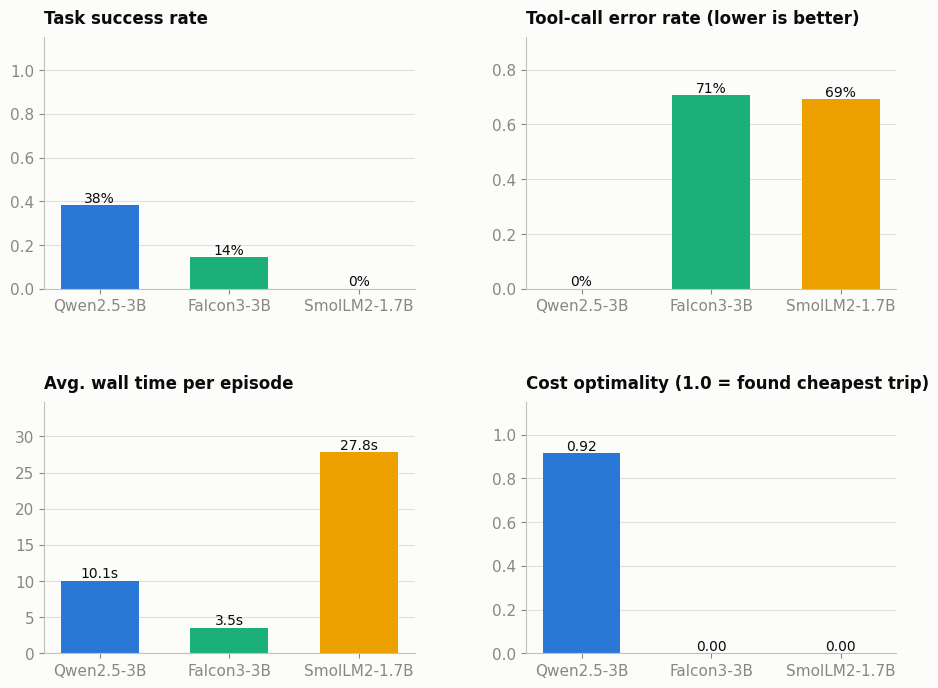

In [39]:
import matplotlib.pyplot as plt
import numpy as np

PALETTE = {"Qwen2.5-3B": "#2a78d6", "Falcon3-3B": "#1baf7a", "SmolLM2-1.7B": "#eda100"}
SURFACE, INK, SEC, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": SEC,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.family": "sans-serif", "font.size": 11,
})


def style_ax(ax, title, ylabel=None, ymax=None):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.xaxis.grid(False)
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", color=INK, pad=10)
    if ylabel:
        ax.set_ylabel(ylabel)
    if ymax:
        ax.set_ylim(0, ymax)


def bars_by_model(ax, values, fmt):
    bars = ax.bar(MODEL_ORDER, [values[m] for m in MODEL_ORDER],
                  color=[PALETTE[m] for m in MODEL_ORDER], width=0.6)
    for b, m in zip(bars, MODEL_ORDER):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(values[m]),
                ha="center", va="bottom", fontsize=10, color=INK)


fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.3)

bars_by_model(axes[0, 0], summary["success_rate"], "{:.0%}")
style_ax(axes[0, 0], "Task success rate", ymax=1.15)

bars_by_model(axes[0, 1], summary["tool_error_rate"], "{:.0%}")
style_ax(axes[0, 1], "Tool-call error rate (lower is better)",
         ymax=max(summary["tool_error_rate"].max() * 1.3, 0.1))

bars_by_model(axes[1, 0], summary["avg_episode_time_s"], "{:.1f}s")
style_ax(axes[1, 0], "Avg. wall time per episode",
         ymax=summary["avg_episode_time_s"].max() * 1.25)

cost_opt = summary["avg_cost_optimality"].fillna(0)
bars_by_model(axes[1, 1], cost_opt, "{:.2f}")
style_ax(axes[1, 1], "Cost optimality (1.0 = found cheapest trip)", ymax=1.15)

fig.savefig(f"{EXPORT_DIR}/chart_headline.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.3 - Robustness

Success rate per prompt variant. A drop from clean to noisy means the model is thrown off by typos and chatter.

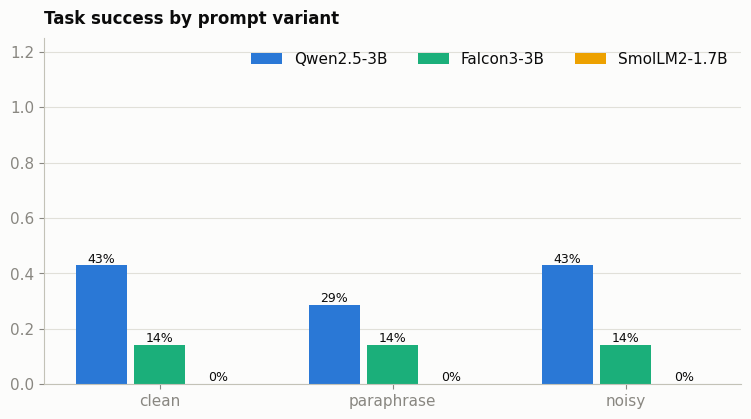

In [40]:
var_order = ["clean", "paraphrase", "noisy"]
pivot_v = (df.pivot_table(index="variant", columns="model", values="success", aggfunc="mean")
             .reindex(var_order)[MODEL_ORDER])

fig, ax = plt.subplots(figsize=(9, 4.5))
x, w = np.arange(len(var_order)), 0.25
for i, m in enumerate(MODEL_ORDER):
    bars = ax.bar(x + (i - 1) * w, pivot_v[m], width=w - 0.03, color=PALETTE[m], label=m)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.0%}",
                ha="center", va="bottom", fontsize=9, color=INK)
ax.set_xticks(x, var_order)
ax.legend(frameon=False, loc="upper right", ncols=3)
style_ax(ax, "Task success by prompt variant", ymax=1.25)
pivot_v.round(3).to_csv(f"{EXPORT_DIR}/success_by_variant.csv")
fig.savefig(f"{EXPORT_DIR}/chart_robustness.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.4 - Budget tiers

Success rate per budget tier. The infeasible column only reaches 100 % if the model reliably declines to book.

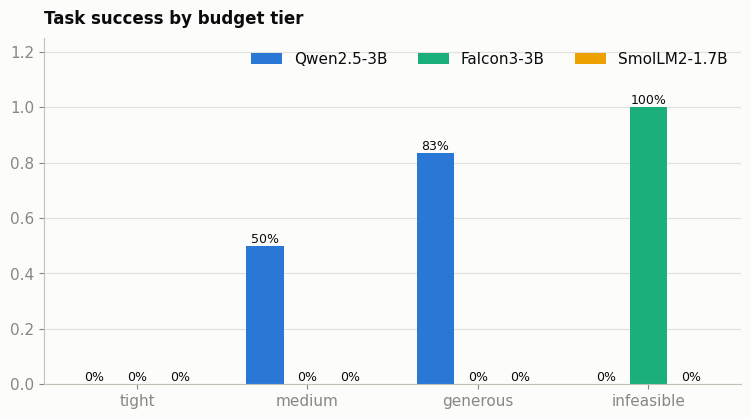

In [41]:
tier_order = ["tight", "medium", "generous", "infeasible"]
pivot_t = (df.pivot_table(index="tier", columns="model", values="success", aggfunc="mean")
             .reindex(tier_order)[MODEL_ORDER])

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(tier_order))
for i, m in enumerate(MODEL_ORDER):
    bars = ax.bar(x + (i - 1) * 0.25, pivot_t[m], width=0.22, color=PALETTE[m], label=m)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.0%}",
                ha="center", va="bottom", fontsize=9, color=INK)
ax.set_xticks(x, tier_order)
ax.legend(frameon=False, loc="upper right", ncols=3)
style_ax(ax, "Task success by budget tier", ymax=1.25)
pivot_t.round(3).to_csv(f"{EXPORT_DIR}/success_by_tier.csv")
fig.savefig(f"{EXPORT_DIR}/chart_tiers.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.5 - Efficiency

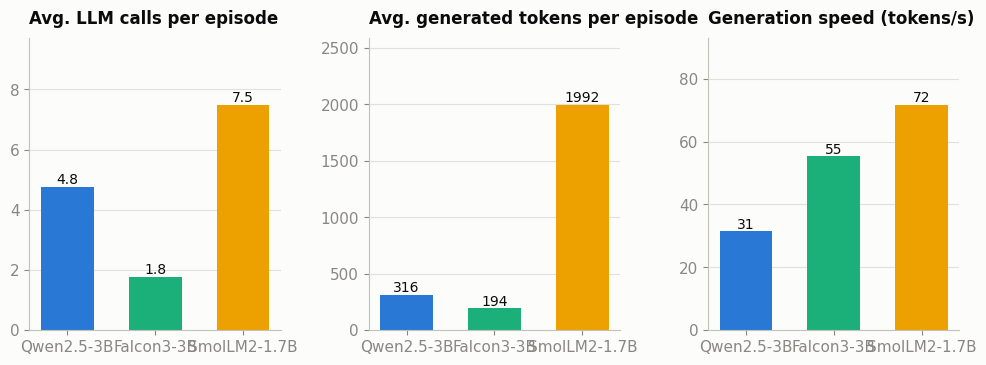

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
fig.subplots_adjust(wspace=0.35)

bars_by_model(axes[0], summary["avg_llm_calls"], "{:.1f}")
style_ax(axes[0], "Avg. LLM calls per episode", ymax=summary["avg_llm_calls"].max() * 1.3)

bars_by_model(axes[1], summary["avg_gen_tokens"], "{:.0f}")
style_ax(axes[1], "Avg. generated tokens per episode", ymax=summary["avg_gen_tokens"].max() * 1.3)

bars_by_model(axes[2], summary["tokens_per_s"], "{:.0f}")
style_ax(axes[2], "Generation speed (tokens/s)", ymax=summary["tokens_per_s"].max() * 1.3)

fig.savefig(f"{EXPORT_DIR}/chart_efficiency.png", dpi=200, bbox_inches="tight")
plt.show()

## 7 - Findings summary

Plain-text summary of the headline numbers, recomputed from the current results.

In [43]:
def pct(x):
    return f"{x:.0%}"

lines = ["=" * 70, "HEADLINE FINDINGS", "=" * 70]
for m in MODEL_ORDER:
    s = summary.loc[m]
    clean = pivot_v.loc["clean", m]
    noisy = pivot_v.loc["noisy", m]
    infeas = pivot_t.loc["infeasible", m]
    lines += [
        f"\n{m}",
        f"  overall success      : {pct(s['success_rate'])}",
        f"  robustness drop      : {pct(clean)} (clean) -> {pct(noisy)} (noisy), "
        f"delta {pct(clean - noisy)}",
        f"  infeasible handling  : declined correctly in {pct(infeas)} of runs",
        f"  over-budget bookings : {pct(s['over_budget_rate'])}",
        f"  tool-call error rate : {pct(s['tool_error_rate'])}   "
        f"parse failures: {pct(s['parse_failure_rate'])}",
        f"  efficiency           : {s['avg_llm_calls']:.1f} LLM calls, "
        f"{s['avg_episode_time_s']:.1f}s per episode, {s['tokens_per_s']:.0f} tok/s",
    ]
    if pd.notna(s["avg_cost_optimality"]):
        lines.append(f"  cost optimality      : {s['avg_cost_optimality']:.2f} "
                     f"(1.00 = always found the cheapest trip)")

lines += [
    "\n" + "=" * 70,
    f"Highest task success : {summary['success_rate'].idxmax()}",
    f"Fastest per episode  : {summary['avg_episode_time_s'].idxmin()}",
    f"Fewest tool errors   : {summary['tool_error_rate'].idxmin()}",
    "=" * 70,
]

report = "\n".join(lines)
with open(f"{EXPORT_DIR}/findings.txt", "w", encoding="utf-8") as f:
    f.write(report)
print(report)

HEADLINE FINDINGS

Qwen2.5-3B
  overall success      : 38%
  robustness drop      : 43% (clean) -> 43% (noisy), delta 0%
  infeasible handling  : declined correctly in 0% of runs
  over-budget bookings : 52%
  tool-call error rate : 0%   parse failures: 2%
  efficiency           : 4.8 LLM calls, 10.1s per episode, 31 tok/s
  cost optimality      : 0.92 (1.00 = always found the cheapest trip)

Falcon3-3B
  overall success      : 14%
  robustness drop      : 14% (clean) -> 14% (noisy), delta 0%
  infeasible handling  : declined correctly in 100% of runs
  over-budget bookings : 0%
  tool-call error rate : 71%   parse failures: 0%
  efficiency           : 1.8 LLM calls, 3.5s per episode, 55 tok/s

SmolLM2-1.7B
  overall success      : 0%
  robustness drop      : 0% (clean) -> 0% (noisy), delta 0%
  infeasible handling  : declined correctly in 0% of runs
  over-budget bookings : 0%
  tool-call error rate : 69%   parse failures: 6%
  efficiency           : 7.5 LLM calls, 27.8s per episode, 